# F8 — GPU ownership, leasing and resale value

Buying and leasing equipment create different payment schedules and ownership rights. A purchase may provide later sale proceeds, while a lease may provide only the right to use the equipment. The comparison depends on both timing and the rights in each agreement.

Read Notebook 2 and F4 first. Here the business buys or leases GPUs. A **lease** is an agreement to use equipment for payments under stated rules.

All prices and terms are **hypothetical**. Buying costs USD 300,000 today. We assume we can sell the equipment for USD 60,000 after 36 months. Leasing costs USD 8,000 at each month-end for 36 months. This lease has no deposit, right to buy, ownership or sale proceeds.

Both choices give the same equipment use and maintenance in our example. We leave out customer receipts and other running costs because they are the same in both choices. Real offers may differ; this comparison deliberately holds those features equal.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from itertools import accumulate

from IPython.display import display

from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.equipment import (
    compare_purchase_lease_cash_flows,
    equipment_exit_equity_usd,
    financed_equipment_exit,
    straight_line_book_values,
)
from liquid_compute.financing import build_amortizing_loan_schedule

purchase_price_usd = 300_000
lease_monthly_usd = 8_000
exit_month = 36
resale_usd = 60_000
annual_discount_rate = 0.12

## Compare total cost before adjusting for timing

For buying, subtract later sale money from the purchase price. For leasing, add all 36 payments. The person leasing gets no equipment sale money under these terms.

Then ask when the money leaves. An upfront purchase commits cash earlier than a series of monthly lease payments. Notebook 2's **present value**, or PV, expresses payments on different dates as today's amounts using a chosen rate.

We choose 12% effective annual discounting for this comparison. That is a way to compare timing, not interest charged by a lender. We add an actual loan later, with a separately stated rate.

In [3]:
purchase_nominal_usd = purchase_price_usd - resale_usd
lease_nominal_usd = lease_monthly_usd * exit_month
purchase_pv_direct_usd = purchase_price_usd - resale_usd / (
    1 + annual_discount_rate
) ** (exit_month / 12)
lease_pv_direct_usd = sum(
    lease_monthly_usd / (1 + annual_discount_rate) ** (m / 12)
    for m in range(1, exit_month + 1)
)
show_finance_table(
    ["Alternative", "Nominal cost (USD)", "PV cost (USD)"],
    [
        ["Purchase", purchase_nominal_usd, purchase_pv_direct_usd],
        ["Lease", lease_nominal_usd, lease_pv_direct_usd],
    ],
)

| Alternative | Nominal cost (USD) | PV cost (USD) |
| --- | --- | --- |
| Purchase | 240,000.00 | 257,293.19 |
| Lease | 288,000.00 | 242,998.03 |

Buying costs **USD 240,000 net**: USD 300,000 minus USD 60,000. Leasing costs **USD 288,000** in total.

But the timing comparison reverses their order. At our chosen rate, buying has a PV cost of **USD 257,293.19**, while leasing has a PV cost of **USD 242,998.03**. Leasing has the lower PV cost because more of its money leaves later.

We count the equipment sale once, at month 36, as money that reduces purchase cost. The lease has no sale receipt. Both schedules cover the same 36 months.

So far there is no loan. This comparison does not say whether a lender would finance either choice.

In [4]:
def procurement(sale, lease=lease_monthly_usd):
    return compare_purchase_lease_cash_flows(
        purchase_price_usd=purchase_price_usd,
        lease_payments_usd=(lease,) * exit_month,
        exit_month=exit_month,
        resale_proceeds_usd=sale,
        has_resale_rights=True,
        annual_discount_rate=annual_discount_rate,
    )


baseline = procurement(resale_usd)


def summary(cases):
    show_finance_table(
        [
            "Case",
            "Purchase nominal (USD)",
            "Lease nominal (USD)",
            "Purchase PV (USD)",
            "Lease PV (USD)",
        ],
        [
            [
                name,
                r.purchase_nominal_cost_usd,
                r.lease_nominal_cost_usd,
                r.purchase_pv_cost_usd,
                r.lease_pv_cost_usd,
            ]
            for name, r in cases.items()
        ],
    )


summary({"USD 60,000 resale": baseline})

| Case | Purchase nominal (USD) | Lease nominal (USD) | Purchase PV (USD) | Lease PV (USD) |
| --- | --- | --- | --- | --- |
| USD 60,000 resale | 240,000.00 | 288,000.00 | 257,293.19 | 242,998.03 |

The shared calculation gives the same costs as our direct arithmetic. The table shows costs as positive numbers. The cash chart shows money paid out as negative amounts.

## Distinguish accounting book value from sale proceeds

**Depreciation** spreads the purchase cost across the months of use for accounting. In our simple example, the books assume USD 60,000 left after 36 months. That gives USD 6,666.67 of depreciation each month.

This book value is not a cash payment or a guaranteed sale price. If the actual selling price changes, we keep the original book assumption for this comparison.

You can change sale proceeds or monthly rent in the inputs. The optional controls keep their own starting values. Both choices still provide the same equipment use.

Illustrative monthly book depreciation: USD 6,666.67
Month-36 book value: USD 60,000.00


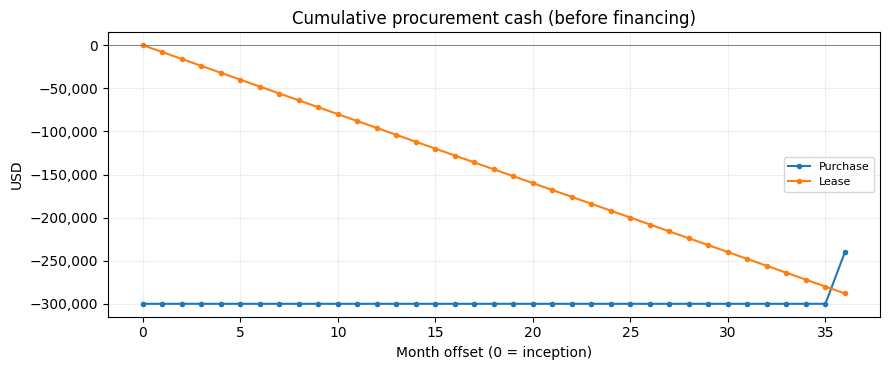

In [5]:
monthly_book_depreciation_usd = (300_000 - 60_000) / 36
book_values = straight_line_book_values(
    purchase_price_usd=300_000, assumed_book_residual_usd=60_000, useful_life_months=36
)
print(
    f"Illustrative monthly book depreciation: USD {monthly_book_depreciation_usd:,.2f}"
)
print(f"Month-36 book value: USD {book_values[-1]:,.2f}")
display(
    plot_finance_series(
        {
            "Purchase": tuple(accumulate(-v for v in baseline.purchase_outflows_usd)),
            "Lease": tuple(accumulate(-v for v in baseline.lease_outflows_usd)),
        },
        title="Cumulative procurement cash (before financing)",
    )
)


def equipment_explorer(
    values, price=purchase_price_usd, horizon=exit_month, rate=annual_discount_rate
):
    from itertools import accumulate

    from liquid_compute.equipment import compare_purchase_lease_cash_flows

    result = compare_purchase_lease_cash_flows(
        purchase_price_usd=price,
        lease_payments_usd=(values["Lease (USD/month)"],) * horizon,
        exit_month=horizon,
        resale_proceeds_usd=values["Resale (USD)"],
        has_resale_rights=True,
        annual_discount_rate=rate,
    )
    return {
        "Purchase cash": tuple(accumulate(-v for v in result.purchase_outflows_usd)),
        "Lease cash": tuple(accumulate(-v for v in result.lease_outflows_usd)),
    }


explore_finance_series(
    {"Resale (USD)": float(resale_usd), "Lease (USD/month)": float(lease_monthly_usd)},
    equipment_explorer,
    title="Procurement cash and ownership rights",
);

The cash lines count actual payments and the single equipment sale. We do not subtract depreciation again: writing down a book value is not paying another bill.

## Experiment 1 — The equipment sells for less

Reduce sale proceeds from USD 60,000 to USD 20,000. Keep the purchase price, months of use and book assumptions unchanged.

This is a hypothetical downside case. It is not a forecast of GPU prices.

In [6]:
downside = procurement(20_000)
summary({"Original resale": baseline, "Lower resale": downside})
print(f"Book value remains USD {book_values[-1]:,.0f}; actual sale cash is USD 20,000.")

| Case | Purchase nominal (USD) | Lease nominal (USD) | Purchase PV (USD) | Lease PV (USD) |
| --- | --- | --- | --- | --- |
| Original resale | 240,000.00 | 288,000.00 | 257,293.19 | 242,998.03 |
| Lower resale | 280,000.00 | 288,000.00 | 285,764.40 | 242,998.03 |

Book value remains USD 60,000; actual sale cash is USD 20,000.


Receiving USD 40,000 less raises net purchase cost from **USD 240,000 to USD 280,000**. The PV change is smaller because the lost receipt is three years away.

The lease payments stay the same. This lease gives its user no sale money to lose.

## Experiment 2 — We still owe money when we sell

Now borrow USD 210,000 at the start. The annual loan rate is 10%, divided by 12 for monthly interest. The loan would normally take 48 months to repay.

We sell in month 36, **after making that month's normal loan payment**. Then we must clear the remaining loan with sale money and, if needed, the owner's money.

Once cleared, there are no later loan payments. We use F1's schedule to find the amount still owed before calling the equipment helper.

In [7]:
loan = build_amortizing_loan_schedule(
    principal_usd=210_000, nominal_annual_interest_rate=0.10, loan_term_months=48
)
exit_debt_usd = loan[36].closing_debt_usd
manual_exit_equity_usd = 20_000 - exit_debt_usd
financed_downside = financed_equipment_exit(
    purchase_price_usd=300_000,
    loan_principal_usd=210_000,
    nominal_annual_interest_rate=0.10,
    loan_term_months=48,
    sale_month=36,
    sale_proceeds_usd=20_000,
)
show_finance_table(
    ["Exit measure", "USD"],
    [
        ["Debt after month-36 scheduled payment", exit_debt_usd],
        ["Sale proceeds", 20_000],
        ["Signed cash to equity from sale", financed_downside.equity_from_sale_usd],
        ["Additional owner cash for payoff", max(0, -manual_exit_equity_usd)],
    ],
)

| Exit measure | USD |
| --- | --- |
| Debt after month-36 scheduled payment | 60,582.25 |
| Sale proceeds | 20,000.00 |
| Signed cash to equity from sale | -40,582.25 |
| Additional owner cash for payoff | 40,582.25 |

After the normal month-36 payment, debt is **USD 60,582.25**. Selling for USD 20,000 leaves **USD 40,582.25 for the owner to supply**.

Negative cash at exit represents additional funding required from the owner. The result retains that shortfall rather than rounding it up to zero. The normal month-36 payment is separate and has already been included.

## Experiment 3 — The equipment sells for more

Try a sale price of USD 100,000 instead. The owner receives the benefit of a higher sale price and bears the cost of a lower one.

Under our lease, its user gets neither change. Real choices may also differ in flexibility or fees for ending early; those features are outside this example.

In [8]:
upside = procurement(100_000)
summary(
    {
        "USD 20,000 sale": downside,
        "USD 60,000 sale": baseline,
        "USD 100,000 sale": upside,
    }
)
show_finance_table(
    ["Sale proceeds (USD)", "Exit cash after debt (USD)"],
    [
        [
            sale,
            equipment_exit_equity_usd(
                sale_proceeds_usd=sale, debt_payoff_usd=exit_debt_usd
            ),
        ]
        for sale in (20_000, 60_000, 100_000)
    ],
)

| Case | Purchase nominal (USD) | Lease nominal (USD) | Purchase PV (USD) | Lease PV (USD) |
| --- | --- | --- | --- | --- |
| USD 20,000 sale | 280,000.00 | 288,000.00 | 285,764.40 | 242,998.03 |
| USD 60,000 sale | 240,000.00 | 288,000.00 | 257,293.19 | 242,998.03 |
| USD 100,000 sale | 200,000.00 | 288,000.00 | 228,821.98 | 242,998.03 |

| Sale proceeds (USD) | Exit cash after debt (USD) |
| --- | --- |
| 20,000.00 | -40,582.25 |
| 60,000.00 | -582.25 |
| 100,000.00 | 39,417.75 |

Each extra dollar from the sale adds one dollar left for the owner after paying the fixed remaining debt. It does not change the book value or refund earlier payments.

Money left at sale is not the whole deal's profit. To judge the full result, include what the owner paid before then too.

The final schedule counts the owner's initial payment, normal loan payments through month 36, the remaining debt payoff and sale proceeds. It stops when the equipment is sold and debt cleared.

If F9 later uses this cash, it must not add the equipment sale a second time.

In [9]:
show_finance_table(
    ["Boundary", "Owner procurement outflow (USD)"],
    [[m, financed_downside.owner_outflows_usd[m]] for m in (0, 1, 35, 36)],
)
print(f"Final modeled cash boundary: {len(financed_downside.owner_outflows_usd) - 1}")

| Boundary | Owner procurement outflow (USD) |
| --- | --- |
| 0.00 | 90,000.00 |
| 1.00 | 5,326.14 |
| 35.00 | 5,326.14 |
| 36.00 | 45,908.40 |

Final modeled cash boundary: 36


## Next — Who gets paid first?

Continue to **F9: Waterfalls, reserves, and investor returns**.

The [SEC's financial-statements guide](https://www.sec.gov/about/reports-publications/investorpubsbegfinstmtguide) explains cash flows and noncash depreciation. Our book calculation is illustrative, not accounting or tax guidance. Ownership rights, loan terms and sale prices here are all hypothetical.